In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import meteostat

In [2]:
metadata = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Plates_1_to_4_metadata_merged_luke.csv",
    index_col=0,
)

metadata = metadata.drop(
    columns=[
        "arb.sort",
        "sample-id",
        "Ambiguous Unstranded",
        "Ambiguous Forward",
        "Multimapping",
        "Unmapped Over Mapped",
    ]
)
metadata["Date and Time"] = metadata["date"] + " " + metadata["time"]
luke_time_data_format = "%-m/%-d/%y %-H:%-M"
metadata["Date and Time"] = pd.to_datetime(
    metadata["Date and Time"], format=luke_time_data_format
)

In [3]:
metadata

,plate.pos,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,No Feature,plate_row,plate_col,Total Reads,Experiment Type,Sample Month,daysincestart,Date and Time
filename,,,,,,,,,,,,,,,,,
A2450525897_n01_LICRNA01_A01,A01,LIC001,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2633048.0,112554.0,A,1,2248661.0,Long Term,November,0,2023-11-01 08:00:00
A2450525897_n01_LICRNA01_B01,B01,LIC002,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,5074184.0,226718.0,B,1,5984566.0,Long Term,November,0,2023-11-01 08:00:00
A2450525897_n01_LICRNA01_C01,C01,LIC003,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,2283008.0,97848.0,C,1,2936453.0,Long Term,November,0,2023-11-01 08:00:00
A2450525897_n01_LICRNA01_D01,D01,LIC004,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,1263467.0,49095.0,D,1,1359823.0,Long Term,November,0,2023-11-01 08:00:00
A2450525897_n01_LICRNA01_E01,E01,LIC005,plant,t01,11/1/23,8:00,LIC_01,LICRNA_01,3004324.0,135512.0,E,1,2680737.0,Long Term,November,0,2023-11-01 08:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B2449500127_n01_LICRNA04_D12,D12,LIC640,plant,c2_t06,3/2/24,16:00,LICCIRC_03,LICRNA_04,3683779.0,579120.0,D,12,7589546.0,Circadian Experiment 2,March,122,2024-03-02 16:00:00
B2449500127_n01_LICRNA04_E12,E12,LIC641,plant,c2_t06,3/2/24,16:00,LICCIRC_03,LICRNA_04,1604732.0,248710.0,E,12,2868917.0,Circadian Experiment 2,March,122,2024-03-02 16:00:00
B2449500127_n01_LICRNA04_F12,F12,LIC642,plant,c2_t06,3/2/24,16:00,LICCIRC_03,LICRNA_04,2279211.0,347737.0,F,12,3742922.0,Circadian Experiment 2,March,122,2024-03-02 16:00:00


In [4]:
start_time = dt.datetime(2023, 10, 1)
end_time = dt.datetime(2024, 4, 30)
luke_apt_point = meteostat.Point(40.73005, -73.99450)
luke_hourly_data = meteostat.Hourly(luke_apt_point, start_time, end_time).fetch()
luke_hourly_data

,temp,dwpt,rhum,prcp,snow,wdir,wspd,wpgt,pres,tsun,coco
time,,,,,,,,,,,
2023-10-01 00:00:00,18.3,15.0,81.0,0.0,<NA>,20.0,11.2,<NA>,1022.0,<NA>,3.0
2023-10-01 01:00:00,18.3,15.0,81.0,0.0,<NA>,0.0,0.0,<NA>,1022.3,<NA>,1.0
2023-10-01 02:00:00,18.3,15.0,81.0,0.0,<NA>,349.0,5.4,<NA>,1022.2,<NA>,1.0
2023-10-01 03:00:00,17.8,14.3,80.0,0.0,<NA>,349.0,7.6,<NA>,1022.1,<NA>,1.0
2023-10-01 04:00:00,17.8,14.3,80.0,0.0,<NA>,260.0,5.4,<NA>,1021.8,<NA>,1.0
...,...,...,...,...,...,...,...,...,...,...,...
2024-04-29 20:00:00,23.9,14.3,55.0,0.0,<NA>,200.0,11.2,<NA>,1014.6,<NA>,3.0
2024-04-29 21:00:00,21.1,16.1,73.0,0.1,<NA>,170.0,11.2,<NA>,1014.8,<NA>,17.0
2024-04-29 22:00:00,18.9,16.1,84.0,0.0,<NA>,152.0,11.2,<NA>,1014.5,<NA>,3.0


In [10]:
# Build snow signal from written records only (2024, local NY dates)
snow_dates = pd.DatetimeIndex([])
snow_dates = snow_dates.union(pd.DatetimeIndex([pd.Timestamp("2024-01-06")]))
snow_dates = snow_dates.union(pd.date_range("2024-01-16", "2024-01-19", freq="D"))
snow_dates = snow_dates.union(pd.date_range("2024-02-12", "2024-02-20", freq="D"))

index_time = luke_hourly_data.index
if getattr(index_time, "tz", None) is None:
    # Meteostat hourly index can be naive UTC; convert to local NY dates for matching
    index_ny = index_time.tz_localize("UTC").tz_convert("America/New_York")
else:
    index_ny = index_time.tz_convert("America/New_York")

snow_mask = index_ny.tz_localize(None).normalize().isin(snow_dates)
luke_hourly_data["snow"] = 0.0
luke_hourly_data.loc[snow_mask, "snow"] = 1.0

luke_hourly_data.loc[snow_mask, ["snow"]].head()

,snow
time,
2024-01-06 05:00:00,1.0
2024-01-06 06:00:00,1.0
2024-01-06 07:00:00,1.0
2024-01-06 08:00:00,1.0
2024-01-06 09:00:00,1.0


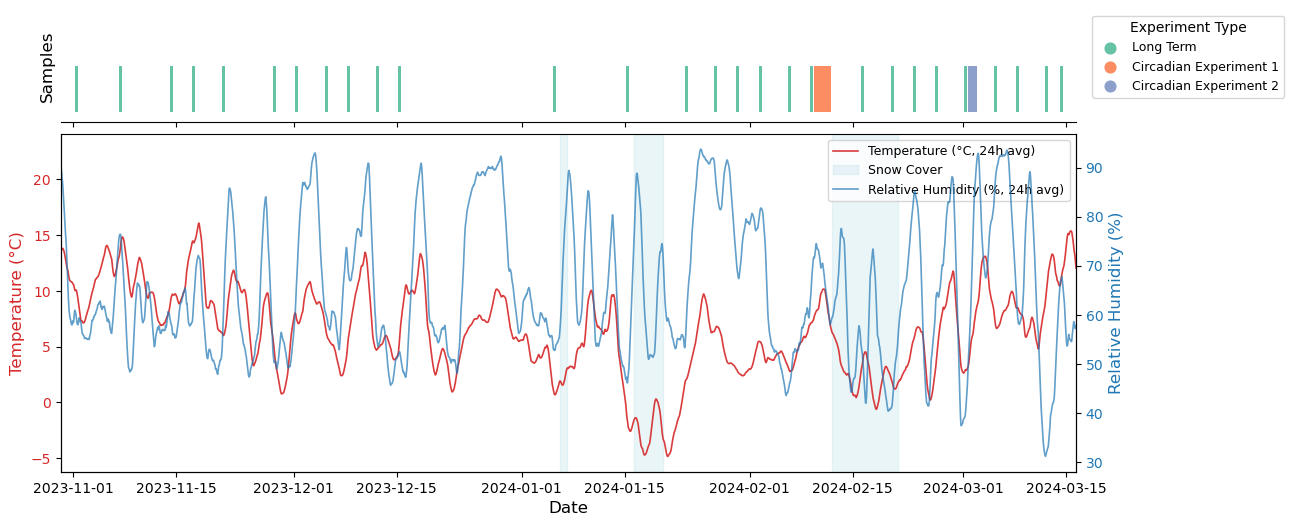

In [13]:
import matplotlib.dates as mdates

# 24-hour rolling average for smoothing
temp_smooth = luke_hourly_data["temp"].rolling(window=24, center=True).mean()
rhum_smooth = luke_hourly_data["rhum"].rolling(window=24, center=True).mean()

# Trim x-axis to sampling range with a small buffer
sampling_min = metadata["Date and Time"].min() - pd.Timedelta(days=2)
sampling_max = metadata["Date and Time"].max() + pd.Timedelta(days=2)

fig, (ax_timeline, ax_temp) = plt.subplots(
    2,
    1,
    figsize=(14, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 3], "hspace": 0.05},
)

# --- Top panel: sampling timeline (short vertical lines) ---
experiment_types = metadata["Experiment Type"].unique()
palette = sns.color_palette("Set2", len(experiment_types))
color_map = dict(zip(experiment_types, palette))

for exp_type in experiment_types:
    subset = metadata[metadata["Experiment Type"] == exp_type]
    for _, row in subset.iterrows():
        ax_timeline.vlines(
            row["Date and Time"],
            ymin=0.1,
            ymax=0.5,
            color=color_map[exp_type],
            linewidth=2,
            alpha=0.7,
        )
    # Invisible scatter for legend entry
    ax_timeline.scatter([], [], label=exp_type, color=color_map[exp_type], s=60)

ax_timeline.set_ylim(0, 1)
ax_timeline.set_yticks([])
ax_timeline.legend(
    title="Experiment Type",
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    fontsize=9,
    title_fontsize=10,
    frameon=True,
)
ax_timeline.set_ylabel("Samples", fontsize=12)
ax_timeline.spines["top"].set_visible(False)
ax_timeline.spines["right"].set_visible(False)
ax_timeline.spines["left"].set_visible(False)

# --- Bottom panel: smoothed temperature & relative humidity ---
color_temp = "tab:red"
color_rhum = "tab:blue"

ax_temp.plot(
    luke_hourly_data.index,
    temp_smooth,
    color=color_temp,
    linewidth=1.2,
    alpha=0.9,
    label="Temperature (°C, 24h avg)",
)
ax_temp.set_ylabel("Temperature (°C)", fontsize=12, color=color_temp)
ax_temp.tick_params(axis="y", labelcolor=color_temp)

ax_rhum = ax_temp.twinx()
ax_rhum.plot(
    luke_hourly_data.index,
    rhum_smooth,
    color=color_rhum,
    linewidth=1.2,
    alpha=0.7,
    label="Relative Humidity (%, 24h avg)",
)
ax_rhum.set_ylabel("Relative Humidity (%)", fontsize=12, color=color_rhum)
ax_rhum.tick_params(axis="y", labelcolor=color_rhum)

# --- Shade snow cover periods (weather panel only) ---
snow_data = luke_hourly_data["snow"].dropna()
snow_present = snow_data > 0
# Find contiguous snow blocks
snow_blocks = snow_present.ne(snow_present.shift()).cumsum()
for _, block in snow_data.groupby(snow_blocks):
    if block.iloc[0] > 0:  # this block has snow
        ax_temp.axvspan(
            block.index.min(),
            block.index.max(),
            color="lightblue",
            alpha=0.25,
            zorder=0,
        )
# Single legend patch for snow
ax_temp.fill_between([], [], color="lightblue", alpha=0.25, label="Snow Cover")

ax_temp.set_xlim(sampling_min, sampling_max)
ax_temp.set_xlabel("Date", fontsize=12)

# Combine legends from both y-axes
lines_temp, labels_temp = ax_temp.get_legend_handles_labels()
lines_rhum, labels_rhum = ax_rhum.get_legend_handles_labels()
ax_temp.legend(
    lines_temp + lines_rhum, labels_temp + labels_rhum, loc="upper right", fontsize=9
)

sns.despine(ax=ax_temp, right=False)
fig.patch.set_facecolor("white")
fig.subplots_adjust(right=0.85)
plt.show()

In [12]:
luke_hourly_data.loc[luke_hourly_data["snow"].isna()]

,temp,dwpt,rhum,prcp,snow,wdir,wspd,wpgt,pres,tsun,coco
time,,,,,,,,,,,
2023-10-01 00:00:00,18.3,15.0,81.0,0.0,<NA>,20.0,11.2,<NA>,1022.0,<NA>,3.0
2023-10-01 01:00:00,18.3,15.0,81.0,0.0,<NA>,0.0,0.0,<NA>,1022.3,<NA>,1.0
2023-10-01 02:00:00,18.3,15.0,81.0,0.0,<NA>,349.0,5.4,<NA>,1022.2,<NA>,1.0
2023-10-01 03:00:00,17.8,14.3,80.0,0.0,<NA>,349.0,7.6,<NA>,1022.1,<NA>,1.0
2023-10-01 04:00:00,17.8,14.3,80.0,0.0,<NA>,260.0,5.4,<NA>,1021.8,<NA>,1.0
...,...,...,...,...,...,...,...,...,...,...,...
2024-04-29 20:00:00,23.9,14.3,55.0,0.0,<NA>,200.0,11.2,<NA>,1014.6,<NA>,3.0
2024-04-29 21:00:00,21.1,16.1,73.0,0.1,<NA>,170.0,11.2,<NA>,1014.8,<NA>,17.0
2024-04-29 22:00:00,18.9,16.1,84.0,0.0,<NA>,152.0,11.2,<NA>,1014.5,<NA>,3.0
